In [ ]:
import pandas as pd

primary_df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/SCMCourseWork/dataFiles/names/names.csv')
names_df = primary_df.copy()

print("Информация о загруженном датафрейме с именами:")
primary_df.info()
display(primary_df.head())

Информация о загруженном датафрейме с именами:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553653 entries, 0 to 553652
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   name    553653 non-null  object
 1   year    553653 non-null  int64 
 2   num     553653 non-null  int64 
 3   total   553653 non-null  int64 
 4   sex     179881 non-null  object
dtypes: int64(3), object(2)
memory usage: 21.1+ MB


,name,year,num,total,sex
0,ЮРИЙ,1932,4245,187203,М
1,АЛЕКСАНДРА,1932,4136,187203,Ж
2,ТАМАРА,1932,4065,187203,Ж
3,ИВАН,1932,3685,187203,М
4,ЛЮДМИЛА,1932,3556,187203,Ж


### Анализ и подготовка данных о именах

In [ ]:
men_df = primary_df[(primary_df['sex'] == 'М') & (primary_df['num'] > 10) &
                    (primary_df['year'] >= 1920) & (primary_df['year'] <= 1979)]

display(men_df.head())
men_df = men_df.drop(columns='sex')
display(men_df.head())


names_popularity = pd.DataFrame(men_df.groupby('name')['num'].sum())
display(names_popularity.head())

popular_names_df = names_popularity.sort_values(by='num', ascending=False).head(20)
display(popular_names_df.head())
popular_names_list = popular_names_df.index.tolist()


,name,year,num,total,sex
0,ЮРИЙ,1932,4245,187203,М
3,ИВАН,1932,3685,187203,М
7,ВАСИЛИЙ,1932,2968,187203,М
8,МИХАИЛ,1932,2949,187203,М
9,АЛЕКСЕЙ,1932,2946,187203,М


,name,year,num,total
0,ЮРИЙ,1932,4245,187203
3,ИВАН,1932,3685,187203
7,ВАСИЛИЙ,1932,2968,187203
8,МИХАИЛ,1932,2949,187203
9,АЛЕКСЕЙ,1932,2946,187203


,num
name,
АББАС,52
АБДУЛ,430
АБДУЛА,89
АБДУЛБЯР,13
АБДУЛЛА,477


,num
name,
АЛЕКСАНДР,780565
ВЛАДИМИР,663717
СЕРГЕЙ,628931
НИКОЛАЙ,434122
ВИКТОР,376084


In [ ]:
outcomes_men_df = pd.pivot_table(
    data=men_df,
    values='num',
    index='year',
    columns='name'
)
display(outcomes_men_df.head(5))

outcomes_men_df = outcomes_men_df[popular_names_list]

display(outcomes_men_df.head(5))
outcomes_men_df.fillna(0, inplace=True)
display(outcomes_men_df.head(5))

name,АББАС,АБДУЛ,АБДУЛА,АБДУЛБЯР,АБДУЛЛА,АБДУЛХАЙ,АБДУРАХМАН,АБРАМ,АБУБАКАР,АВГУСТ,...,ЮСИФ,ЮСУП,ЮСУФ,ЯКОВ,ЯКУБ,ЯН,ЯНИС,ЯРОСЛАВ,ЯША,ЯШАР
year,,,,,,,,,,,,,,,,,,,,,
1920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0,NaN,NaN,...,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN
1921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,NaN,NaN,...,NaN,NaN,NaN,166.0,NaN,NaN,NaN,NaN,NaN,NaN
1922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0,NaN,NaN,...,NaN,NaN,NaN,171.0,NaN,NaN,NaN,NaN,NaN,NaN
1923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.0,NaN,NaN,...,NaN,NaN,NaN,157.0,NaN,NaN,NaN,NaN,NaN,NaN
1924,NaN,17.0,NaN,NaN,NaN,NaN,NaN,37.0,NaN,NaN,...,NaN,NaN,NaN,161.0,NaN,NaN,NaN,NaN,NaN,NaN


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,ИГОРЬ,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ
year,,,,,,,,,,,,,,,,,,,,
1920,1461.0,1082.0,839.0,2314.0,616.0,1050.0,290.0,253.0,1321.0,465.0,156.0,407.0,304.0,38.0,51.0,60.0,2126.0,1472.0,593.0,80.0
1921,1858.0,1365.0,1057.0,2817.0,942.0,1316.0,423.0,310.0,1646.0,575.0,201.0,471.0,440.0,76.0,97.0,76.0,2133.0,1698.0,733.0,117.0
1922,2170.0,1604.0,1207.0,3375.0,1100.0,1477.0,495.0,361.0,1888.0,838.0,205.0,518.0,478.0,91.0,140.0,84.0,2570.0,1829.0,833.0,161.0
1923,2490.0,2140.0,1346.0,3869.0,1539.0,1541.0,751.0,361.0,2163.0,1084.0,232.0,598.0,708.0,88.0,139.0,149.0,2832.0,1963.0,1050.0,181.0
1924,2819.0,3813.0,1550.0,4631.0,2146.0,2097.0,982.0,388.0,2366.0,1258.0,283.0,663.0,830.0,118.0,152.0,182.0,3033.0,2557.0,1226.0,241.0


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,ИГОРЬ,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ
year,,,,,,,,,,,,,,,,,,,,
1920,1461.0,1082.0,839.0,2314.0,616.0,1050.0,290.0,253.0,1321.0,465.0,156.0,407.0,304.0,38.0,51.0,60.0,2126.0,1472.0,593.0,80.0
1921,1858.0,1365.0,1057.0,2817.0,942.0,1316.0,423.0,310.0,1646.0,575.0,201.0,471.0,440.0,76.0,97.0,76.0,2133.0,1698.0,733.0,117.0
1922,2170.0,1604.0,1207.0,3375.0,1100.0,1477.0,495.0,361.0,1888.0,838.0,205.0,518.0,478.0,91.0,140.0,84.0,2570.0,1829.0,833.0,161.0
1923,2490.0,2140.0,1346.0,3869.0,1539.0,1541.0,751.0,361.0,2163.0,1084.0,232.0,598.0,708.0,88.0,139.0,149.0,2832.0,1963.0,1050.0,181.0
1924,2819.0,3813.0,1550.0,4631.0,2146.0,2097.0,982.0,388.0,2366.0,1258.0,283.0,663.0,830.0,118.0,152.0,182.0,3033.0,2557.0,1226.0,241.0


In [ ]:
predictors = outcomes_men_df.loc[outcomes_men_df.index <= 1960]
predictors['predictor_label'] = (predictors.index - 1920) // 5

display(predictors.head(5))
display(predictors.tail(5))

predictors = predictors.groupby('predictor_label').sum()
display(predictors.head(10))


/tmp/ipykernel_10644/1183946285.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictors['predictor_label'] = (predictors.index - 1920) // 5


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,...,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ,predictor_label
year,,,,,,,,,,,,,,,,,,,,,
1920,1461.0,1082.0,839.0,2314.0,616.0,1050.0,290.0,253.0,1321.0,465.0,...,407.0,304.0,38.0,51.0,60.0,2126.0,1472.0,593.0,80.0,0
1921,1858.0,1365.0,1057.0,2817.0,942.0,1316.0,423.0,310.0,1646.0,575.0,...,471.0,440.0,76.0,97.0,76.0,2133.0,1698.0,733.0,117.0,0
1922,2170.0,1604.0,1207.0,3375.0,1100.0,1477.0,495.0,361.0,1888.0,838.0,...,518.0,478.0,91.0,140.0,84.0,2570.0,1829.0,833.0,161.0,0
1923,2490.0,2140.0,1346.0,3869.0,1539.0,1541.0,751.0,361.0,2163.0,1084.0,...,598.0,708.0,88.0,139.0,149.0,2832.0,1963.0,1050.0,181.0,0
1924,2819.0,3813.0,1550.0,4631.0,2146.0,2097.0,982.0,388.0,2366.0,1258.0,...,663.0,830.0,118.0,152.0,182.0,3033.0,2557.0,1226.0,241.0,0


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,...,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ,predictor_label
year,,,,,,,,,,,,,,,,,,,,,
1956,27040.0,21491.0,21231.0,13536.0,11468.0,5590.0,8315.0,4674.0,7919.0,6429.0,...,1357.0,4778.0,5540.0,2229.0,3785.0,2331.0,3367.0,2169.0,3215.0,7
1957,27029.0,20611.0,21684.0,12608.0,11008.0,6327.0,8214.0,5499.0,8106.0,5910.0,...,1594.0,4871.0,5430.0,2315.0,3540.0,2459.0,3507.0,2055.0,3183.0,7
1958,27324.0,19941.0,24600.0,12112.0,10470.0,6582.0,8300.0,7302.0,8564.0,5450.0,...,1751.0,4885.0,5399.0,2891.0,3422.0,2431.0,3325.0,2121.0,3273.0,7
1959,25350.0,18534.0,24342.0,11071.0,9600.0,6655.0,7879.0,9701.0,8294.0,5007.0,...,1864.0,4668.0,5731.0,3308.0,3327.0,2395.0,3197.0,1966.0,3429.0,7
1960,25388.0,18451.0,26089.0,10341.0,9062.0,7597.0,7858.0,11781.0,8572.0,4573.0,...,2635.0,4637.0,5507.0,4312.0,3657.0,2353.0,3096.0,2020.0,3716.0,8


name,АЛЕКСАНДР,ВЛАДИМИР,СЕРГЕЙ,НИКОЛАЙ,ВИКТОР,АЛЕКСЕЙ,ЮРИЙ,АНДРЕЙ,МИХАИЛ,АНАТОЛИЙ,ИГОРЬ,ДМИТРИЙ,ЕВГЕНИЙ,ВАЛЕРИЙ,ОЛЕГ,ВЯЧЕСЛАВ,ИВАН,ВАСИЛИЙ,БОРИС,ГЕННАДИЙ
predictor_label,,,,,,,,,,,,,,,,,,,,
0,10798.0,10004.0,5999.0,17006.0,6343.0,7481.0,2941.0,1673.0,9384.0,4220.0,1077.0,2657.0,2760.0,411.0,579.0,551.0,12694.0,9519.0,4435.0,780.0
1,23105.0,26741.0,10768.0,37622.0,20784.0,15843.0,10982.0,2736.0,17759.0,15483.0,2665.0,5249.0,7892.0,1204.0,1585.0,1983.0,23332.0,18813.0,10047.0,3026.0
2,22856.0,33144.0,8465.0,34512.0,26203.0,13629.0,19162.0,2084.0,14039.0,22771.0,4063.0,3872.0,10963.0,1683.0,2717.0,3593.0,17715.0,14003.0,13165.0,5187.0
3,32657.0,62266.0,10237.0,38995.0,46933.0,13546.0,40866.0,2609.0,14143.0,45350.0,9021.0,3911.0,20570.0,12430.0,7301.0,16800.0,14321.0,11308.0,20775.0,13360.0
4,29901.0,48234.0,9217.0,29448.0,33827.0,9748.0,25087.0,2442.0,11595.0,29575.0,6161.0,2848.0,13744.0,20263.0,4676.0,15381.0,8973.0,7996.0,13822.0,9930.0
5,75302.0,90224.0,26485.0,55682.0,56261.0,16358.0,35283.0,5186.0,25175.0,39896.0,9339.0,4509.0,21987.0,27496.0,6769.0,19005.0,9284.0,11373.0,17989.0,13269.0
6,114749.0,106575.0,62607.0,63953.0,58635.0,22465.0,37956.0,10701.0,31589.0,36979.0,14842.0,5319.0,23449.0,28971.0,8744.0,19412.0,10565.0,14596.0,12975.0,14035.0
7,133615.0,103119.0,110989.0,62628.0,54259.0,30515.0,41257.0,31236.0,40259.0,29598.0,29112.0,7908.0,24299.0,28318.0,12683.0,18234.0,11872.0,16605.0,10716.0,16360.0
8,25388.0,18451.0,26089.0,10341.0,9062.0,7597.0,7858.0,11781.0,8572.0,4573.0,9731.0,2635.0,4637.0,5507.0,4312.0,3657.0,2353.0,3096.0,2020.0,3716.0


In [ ]:
import matplotlib
def plot(synth_tables):
    synth_Y1, Y1 = synth_tables[0], synth_tables[1]
    plt.plot(range(len(synth_Y1)),synth_Y1, 'r--', label="Synthetic Control")
    plt.plot(range(len(synth_Y1)),Y1, 'b-', label="Actual Data")
    plt.title("Example Synthetic Control Model")
    plt.ylabel("Y axis")
    plt.xlabel("X axis")
    plt.legend(loc='upper left')
    plt.show()


In [ ]:
import sys
import importlib
sys.path.append('/content/drive/MyDrive/ColabNotebooks/SCMCourseWork/src/scmlib')
# Принудительно перезагружаем модуль main, чтобы убедиться, что используется новая версия
if 'scmsolver' in sys.modules:
    scmsolver = importlib.reload(sys.modules['scmsolver'])
else:
    import scmsolver

from scmsolver import scm_solve
from scmsolver import basic_dataprep
X0, X1, Y0_pre, Y1_pre, Y0, Y1 = scmsolver.basic_dataprep(predictors,
                             outcomes_men_df,
                             'ЮРИЙ',
                             predictors.columns.drop('ЮРИЙ').tolist(),
                             list(range(1920, 1961)), list(range(1920, 1980)))
res = scmsolver.scm_solve(Y0.values, Y0_pre.values, Y1_pre.values, X0.values, X1.values) # returned: {V, W, Y_1_synth}

# synth_tables = synth_Y1, Y1, matrix_V, vector_W, predictors_table, outcomes_table
names_table1 = [res['Y_1_synth'], Y1, res['V'], res['W'], predictors, outcomes_men_df]

plot(names_table1)

n_features = x0.shape[0]: 9, n_donors = x0.shape[1]: 19


/usr/local/lib/python3.13/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Оптимизация V и W успешно завершена(50 iterations). returned: {V, W, Y_1_synth}



NameError: name 'plt' is not defined

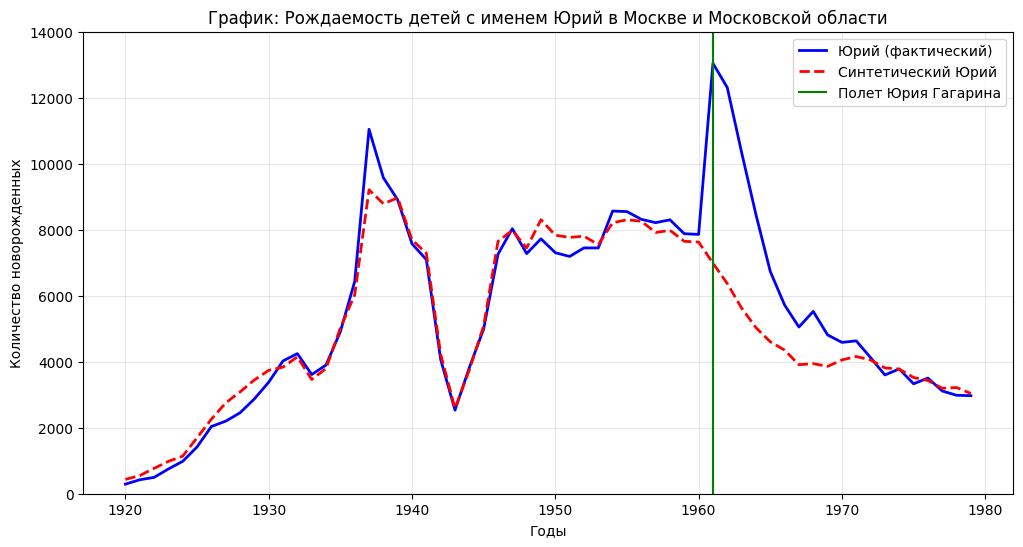

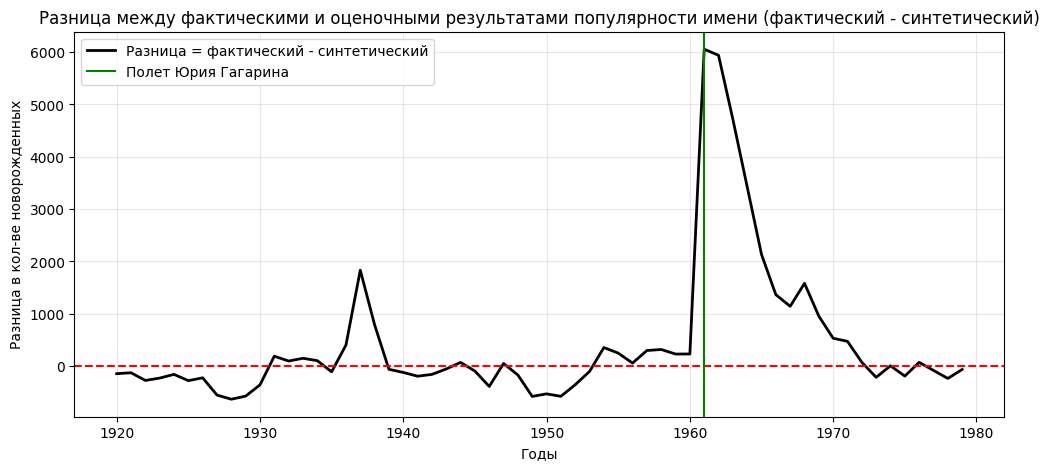

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# names_table1 = synth_Y1, Y1, matrix_V, vector_W, predictors_table, outcomes_table
# 1. Расчет временного ряда
years = np.arange(1920, 1980)
# Y_1_synth = Y_1 @ W_opt_abadie
Y1_synth = names_table1[0]
Y1 = names_table1[1]
# 2. Построение графика:
plt.figure(figsize=(12, 6))
plt.plot(years, Y1, 'b-', label='Юрий (фактический)', linewidth=2)
plt.plot(years, Y1_synth, 'r--', label='Синтетический Юрий', linewidth=2)
plt.axvline(x=1961, color='green', linestyle='-', label='Полет Юрия Гагарина')
plt.title('График: Рождаемость детей с именем Юрий в Москве и Московской области')
plt.xlabel('Годы')
plt.ylabel('Количество новорожденных')
plt.ylim(0, 14000)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("my_namesmain.png", dpi=600, bbox_inches="tight")
plt.show()

# 3. График разности (Gap Plot)
gap = Y1 - Y1_synth

plt.figure(figsize=(12, 5))
plt.plot(years, gap, 'k-', linewidth=2, label='Разница = фактический - синтетический')
plt.axhline(y=0, color='red', linestyle='--')
plt.axvline(x=1961, color='green', linestyle='-', label='Полет Юрия Гагарина')
plt.title('Разница между фактическими и оценочными результатами популярности имени (фактический - синтетический)')
plt.xlabel('Годы')
plt.ylabel('Разница в кол-ве новорожденных')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("my_namesgap.png", dpi=600, bbox_inches="tight")
plt.show()